# Waterfall Plot Gallery

Waterfall plots show how a sequence of positive and negative steps moves a metric from a starting value to an ending value. Each bar floats at the running total left by the previous step, so the eye reads both the size of each step and where the metric sits at every point along the chain.

Waterfall plots excel at:
- **Revenue and margin bridges**: explain why this period's number differs from last period's
- **Driver decomposition**: surface which factors are pulling a KPI up or dragging it down
- **Budget variance**: walk an actual back to the plan, line item by line item
- **Performance audit trails**: keep every contributing step visible rather than burying them in a single net change

In [ ]:
import matplotlib.pyplot as plt

from openretailscience.plots import waterfall

## Basic Waterfall Chart

The simplest call: a list of `amounts` and a matching list of `labels`. Each bar is colored using the configured semantic palette — positive amounts in green, negative amounts in red — so the direction of each step reads at a glance without needing a legend.

The first bar starts at zero and acts as the baseline. Subsequent bars float at the running cumulative total, so the chart works as a self-contained bridge from a starting position to an ending one.

---

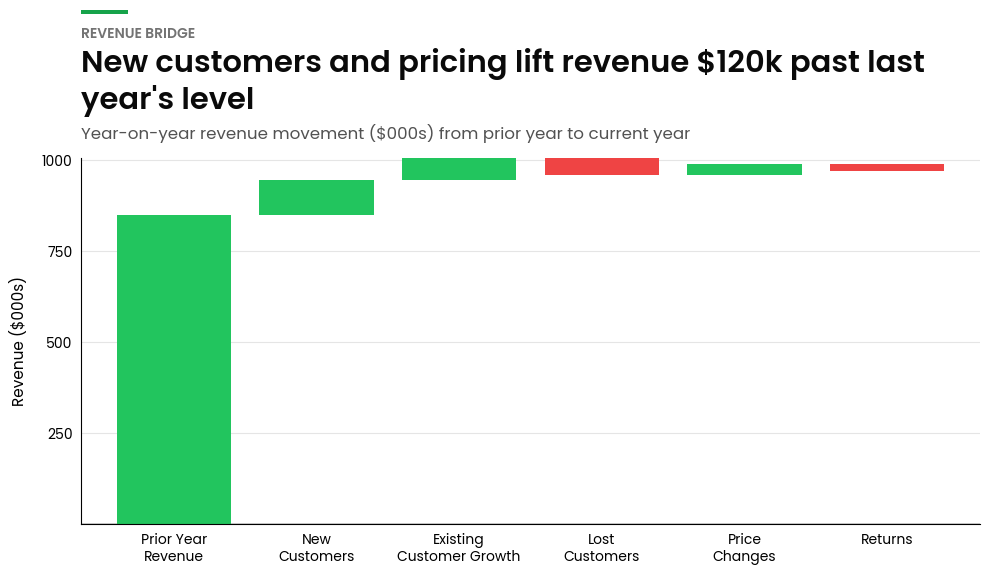

In [ ]:
# Last year's revenue plus the drivers that take us to this year's number.
# 850 + 95 + 60 - 45 + 30 - 20 = 970, so revenue lifts $120k year on year.
amounts = [850, 95, 60, -45, 30, -20]
labels = [
    "Prior Year Revenue",
    "New Customers",
    "Existing Customer Growth",
    "Lost Customers",
    "Price Changes",
    "Returns",
]

waterfall.plot(
    amounts=amounts,
    labels=labels,
    eyebrow="Revenue bridge",
    title="New customers and pricing lift revenue $120k past last year's level",
    subtitle="Year-on-year revenue movement ($000s) from prior year to current year",
    y_label="Revenue ($000s)",
    figsize=(10, 6),
)
plt.show()

## Data Label Formats

Use `data_label_format` to attach values to each bar. `"absolute"` shows the raw number, `"percentage"` shows each step as a share of the net total change, and `"both"` combines them in a single label like `42 (60%)`. Pass `None` (the default) to skip data labels entirely when the chart is busy enough already.

Percentages are computed against the sum of all amounts (the net change), which reads most cleanly when the sequence is mostly additive — like a breakdown of how each driver contributed to a year's growth.

---

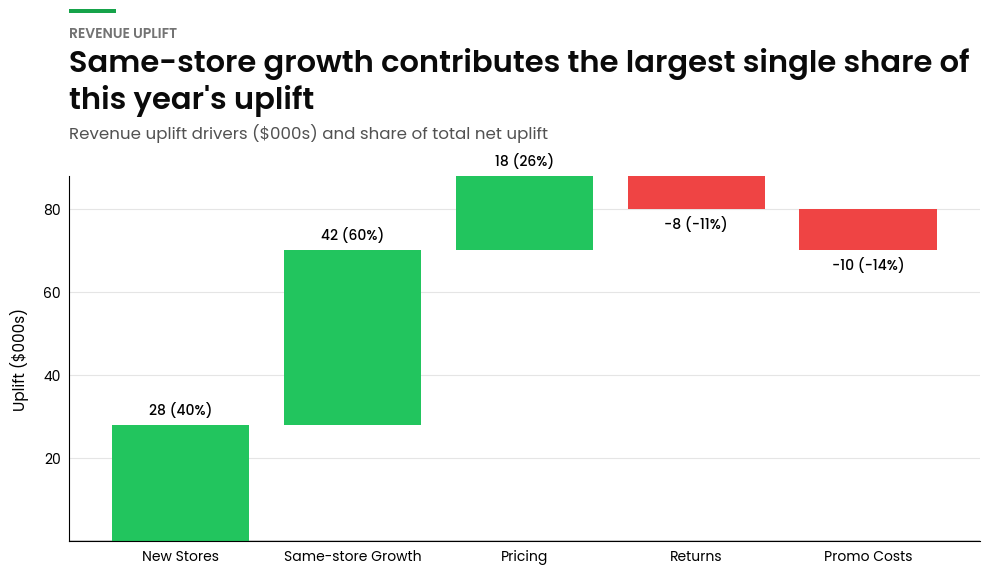

In [ ]:
# Pure additive-then-corrective sequence so the percent-of-net labels
# read as 'share of this year's revenue uplift'.
# 28 + 42 + 18 - 8 - 10 = 70, so same-store growth alone is 60% of the uplift.
amounts = [28, 42, 18, -8, -10]
labels = [
    "New Stores",
    "Same-store Growth",
    "Pricing",
    "Returns",
    "Promo Costs",
]

waterfall.plot(
    amounts=amounts,
    labels=labels,
    data_label_format="both",
    eyebrow="Revenue uplift",
    title="Same-store growth contributes the largest single share of this year's uplift",
    subtitle="Revenue uplift drivers ($000s) and share of total net uplift",
    y_label="Uplift ($000s)",
    figsize=(10, 6),
)
plt.show()

## Net Bar Display

Set `display_net_bar=True` to append an extra bar at the right that shows the final cumulative total as a single value. The net bar is rendered in the configured difference color so it stands out as a summary rather than another step. Useful when the audience cares about the ending number as much as the path that got there.

---

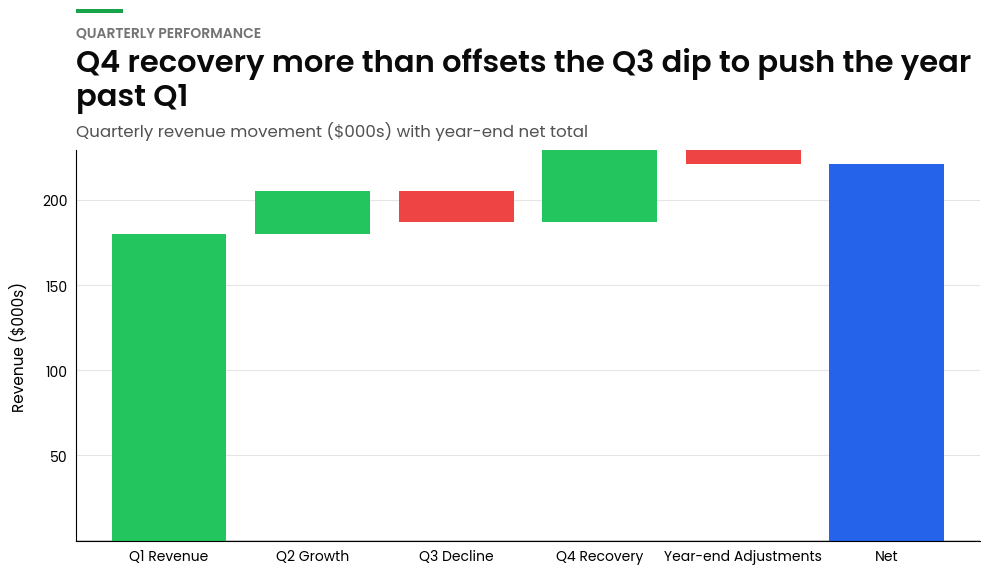

In [ ]:
# 180 + 25 - 18 + 42 - 8 = 221. Q4 recovery (+42) more than offsets Q3 decline (-18).
amounts = [180, 25, -18, 42, -8]
labels = [
    "Q1 Revenue",
    "Q2 Growth",
    "Q3 Decline",
    "Q4 Recovery",
    "Year-end Adjustments",
]

waterfall.plot(
    amounts=amounts,
    labels=labels,
    display_net_bar=True,
    eyebrow="Quarterly performance",
    title="Q4 recovery more than offsets the Q3 dip to push the year past Q1",
    subtitle="Quarterly revenue movement ($000s) with year-end net total",
    y_label="Revenue ($000s)",
    figsize=(10, 6),
)
plt.show()

## Net Line Display

Set `display_net_line=True` to draw a horizontal dashed line at the final cumulative total. Unlike `display_net_bar`, this leaves the chart's bar count alone and instead overlays a reference line that lets the eye check whether each subsequent step lifts above or drops below the ending value. Pair it with an absolute label format so the reader can match each bar's number to the line.

---

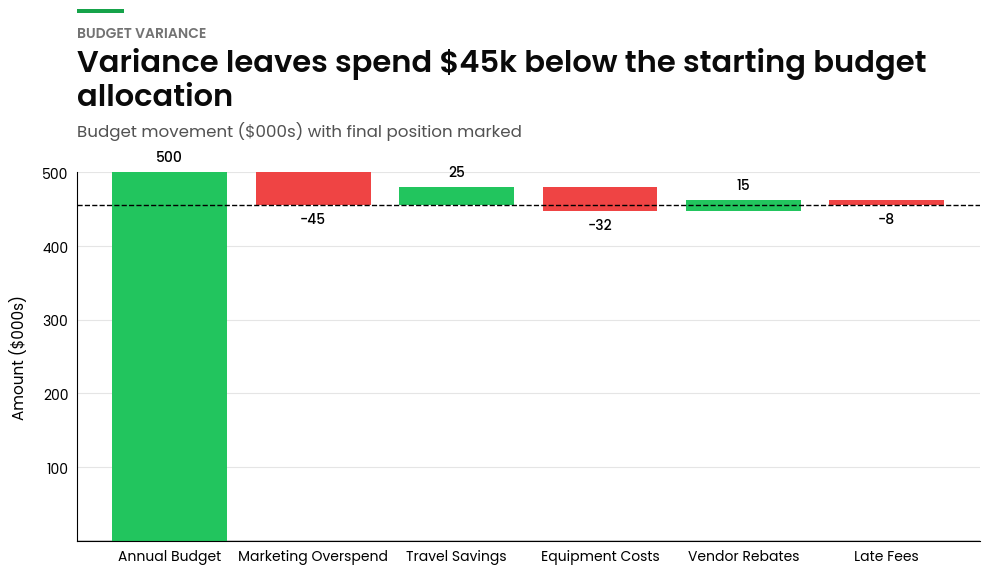

In [ ]:
# 500 - 45 + 25 - 32 + 15 - 8 = 455. Final spend is $45k below the $500k budget.
amounts = [500, -45, 25, -32, 15, -8]
labels = [
    "Annual Budget",
    "Marketing Overspend",
    "Travel Savings",
    "Equipment Costs",
    "Vendor Rebates",
    "Late Fees",
]

waterfall.plot(
    amounts=amounts,
    labels=labels,
    display_net_line=True,
    data_label_format="absolute",
    eyebrow="Budget variance",
    title="Variance leaves spend $45k below the starting budget allocation",
    subtitle="Budget movement ($000s) with final position marked",
    y_label="Amount ($000s)",
    figsize=(10, 6),
)
plt.show()

## Keep Zero Amounts Visible

By default, zero-amount entries are dropped before plotting because they would render as invisible bars. Set `remove_zero_amounts=False` to keep them in the chain — useful for audit trails where the zero items are meaningful ("reviewed and confirmed no impact") rather than just absent.

---

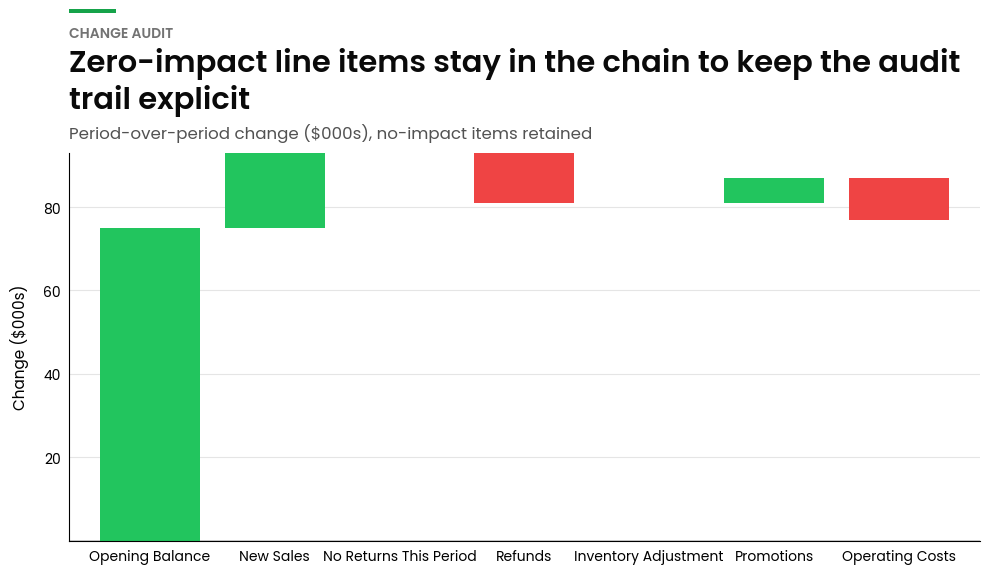

In [ ]:
# Two explicit zeros mark line items that were reviewed and confirmed as no-impact.
amounts = [75, 18, 0, -12, 0, 6, -10]
labels = [
    "Opening Balance",
    "New Sales",
    "No Returns This Period",
    "Refunds",
    "Inventory Adjustment",
    "Promotions",
    "Operating Costs",
]

waterfall.plot(
    amounts=amounts,
    labels=labels,
    remove_zero_amounts=False,
    eyebrow="Change audit",
    title="Zero-impact line items stay in the chain to keep the audit trail explicit",
    subtitle="Period-over-period change ($000s), no-impact items retained",
    y_label="Change ($000s)",
    figsize=(10, 6),
)
plt.show()